# Microwave dielectric properties of natural materials

An undergraduate computational companion to Ulaby & Long, Chapter 4. The notebook moves from pure substances to mixtures, then applies the models to ice, snow, rock, vegetation, and canopies. NavaSAR writes passive loss as $\epsilon=\epsilon'+j\epsilon''$. Some references use the opposite sign because they assume a different time convention.

In [1]:
import sys
from pathlib import Path
try:
    import navasar
except ModuleNotFoundError:
    root = next((p for p in (Path.cwd(), Path.cwd().parent) if (p/'navasar').is_dir()), None)
    if root is None:
        raise ModuleNotFoundError('Run: python -m pip install -e .[notebooks]')
    sys.path.insert(0, str(root))
import numpy as np
import matplotlib.pyplot as plt
from navasar.materials import *
plt.rcParams.update({'figure.figsize': (8, 4.5), 'axes.grid': True})
print('Python:', sys.executable)
print('NavaSAR:', navasar.__file__)

Python: /home/mohammad/anaconda3/envs/code/bin/python
NavaSAR: /home/mohammad/Software/NavaSAR/navasar/__init__.py


## 1. Storage and loss

The real part $\epsilon'$ governs phase velocity and refraction. The loss factor $\epsilon''$ controls absorption. Liquid-water molecules rotate in response to an alternating field, producing a strong frequency-dependent relaxation. Ice cannot reorient as freely and is much less lossy.

Text(0.5, 0.98, 'Liquid water and pure ice respond very differently')

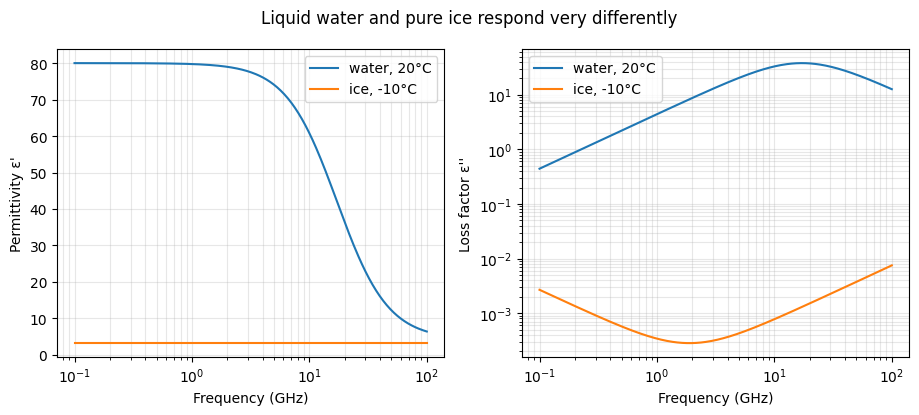

In [2]:
f = np.logspace(-1, 2, 300)
water = pure_water_permittivity(f, 20)
ice = pure_ice_permittivity(f, -10)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogx(f, water.real, label='water, 20°C'); ax[0].semilogx(f, ice.real, label='ice, -10°C')
ax[1].loglog(f, water.imag, label='water, 20°C'); ax[1].loglog(f, ice.imag, label='ice, -10°C')
ax[0].set(xlabel='Frequency (GHz)', ylabel="Permittivity ε'"); ax[1].set(xlabel='Frequency (GHz)', ylabel="Loss factor ε''")
for a in ax: a.legend(); a.grid(True, which='both', alpha=.3)
fig.suptitle('Liquid water and pure ice respond very differently')

## 2. Temperature changes water and ice differently

Water relaxation shifts with temperature. Pure-ice permittivity stays near 3.2, but its already-small loss changes substantially. Always keep frequency and temperature attached to a dielectric value.

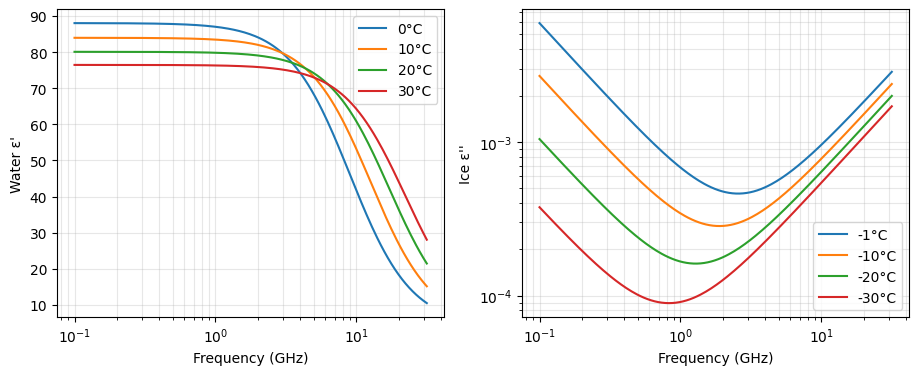

In [3]:
freq = np.logspace(-1, 1.5, 200)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for T in (0, 10, 20, 30):
    eps = pure_water_permittivity(freq, T); ax[0].semilogx(freq, eps.real, label=f'{T}°C')
for T in (-1, -10, -20, -30):
    eps = pure_ice_permittivity(freq, T); ax[1].loglog(freq, eps.imag, label=f'{T}°C')
ax[0].set(xlabel='Frequency (GHz)', ylabel="Water ε'"); ax[1].set(xlabel='Frequency (GHz)', ylabel="Ice ε''")
for a in ax: a.legend(); a.grid(True, which='both', alpha=.3)

## 3. Inclusion geometry

A mixture is not determined by its ingredients alone. An ellipsoid has depolarization factors $L_a+L_b+L_c=1$. Spheres respond equally along every axis; discs and needles do not. Random orientation averages the three responses.

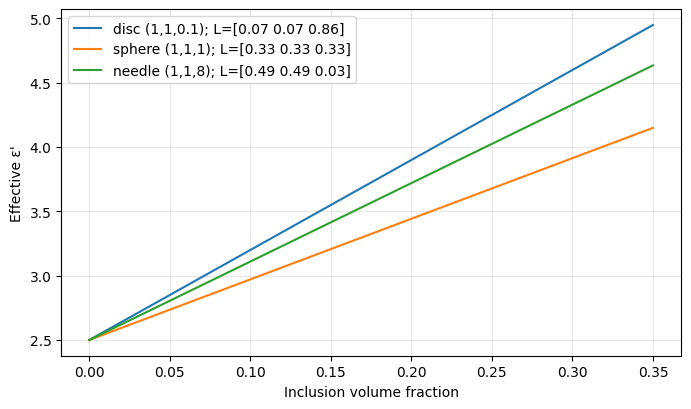

In [4]:
fraction = np.linspace(0, .35, 120)
shapes = {'disc (1,1,0.1)': (1,1,.1), 'sphere (1,1,1)': (1,1,1), 'needle (1,1,8)': (1,1,8)}
for label, axes in shapes.items():
    L = depolarization_factors(*axes)
    mixed = dilute_ellipsoid_mixing(2.5+.02j, 15+2j, fraction, L)
    plt.plot(fraction, mixed.real, label=f'{label}; L={np.round(L,2)}')
plt.xlabel('Inclusion volume fraction'); plt.ylabel("Effective ε'"); plt.legend(); plt.grid(alpha=.3)

## 4. Mixing rules are assumptions

The dilute model neglects strong inclusion interactions. Polder–van Santen is symmetric between phases. TVB imposes a host/inclusion geometry. Their disagreement is a useful estimate of structural-model uncertainty, not a numerical error.

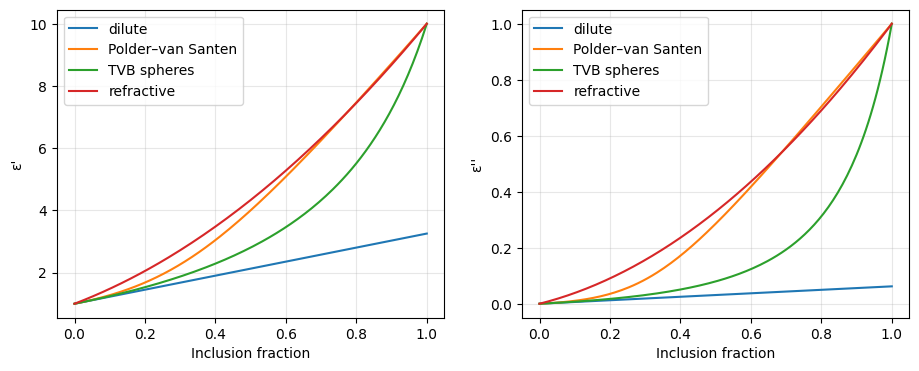

In [5]:
vf = np.linspace(0, 1, 151)
host, inclusion = 1+0j, 10+1j
dilute = dilute_ellipsoid_mixing(host, inclusion, vf)
pvs = np.array([polder_van_santen([host, inclusion], [1-x, x]) for x in vf])
tvb = tvb_mixing(host, inclusion, vf, 'spheres')
refr = np.array([refractive_mixture([host, inclusion], [1-x, x]) for x in vf])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for y, name in ((dilute,'dilute'),(pvs,'Polder–van Santen'),(tvb,'TVB spheres'),(refr,'refractive')):
    ax[0].plot(vf, y.real, label=name); ax[1].plot(vf, y.imag, label=name)
ax[0].set(xlabel='Inclusion fraction', ylabel="ε'"); ax[1].set(xlabel='Inclusion fraction', ylabel="ε''")
for a in ax: a.legend(); a.grid(alpha=.3)

## 5. The generalized power-law mixing formula

Section 4-4.4 of Ulaby & Long collects many mixing formulas into one family, Eq. (4.45): $\varepsilon_m^\alpha=\varepsilon_h^\alpha+v_i(\varepsilon_i^\alpha-\varepsilon_h^\alpha)$. Setting $\alpha=1$ gives the *linear* model, $\alpha=1/2$ gives the *refractive* model (since $\varepsilon^{1/2}=n$ is the refractive index), and $\alpha=1/3$ gives the *cubic* model. The same formula, with $\alpha=0.65$, underlies the Dobson wet-soil model used in Section 9 below.

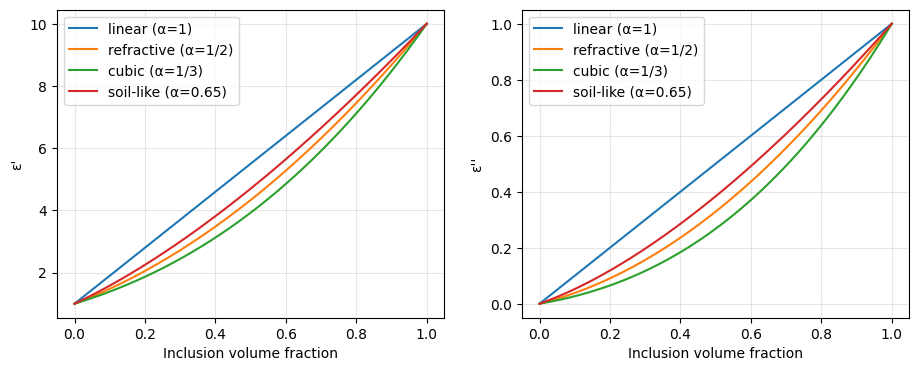

In [6]:
vi = np.linspace(0, 1, 151)
host, inclusion = 1 + 0j, 10 + 1j
alphas = {'linear (α=1)': 1.0, 'refractive (α=1/2)': 0.5,
          'cubic (α=1/3)': 1/3, 'soil-like (α=0.65)': 0.65}
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for label, alpha in alphas.items():
    eps_m = generalized_dielectric_mixing(host, inclusion, vi, alpha)
    ax[0].plot(vi, eps_m.real, label=label)
    ax[1].plot(vi, eps_m.imag, label=label)
ax[0].set(xlabel='Inclusion volume fraction', ylabel="ε'")
ax[1].set(xlabel='Inclusion volume fraction', ylabel="ε''")
for a in ax: a.legend(); a.grid(alpha=.3)

## 6. Sea ice: temperature controls brine

Freezing excludes salt from the ice lattice and concentrates it in liquid pockets. Cooling changes equilibrium brine salinity and brine volume. Even a small liquid fraction dominates the loss because brine is far more conductive than pure ice.

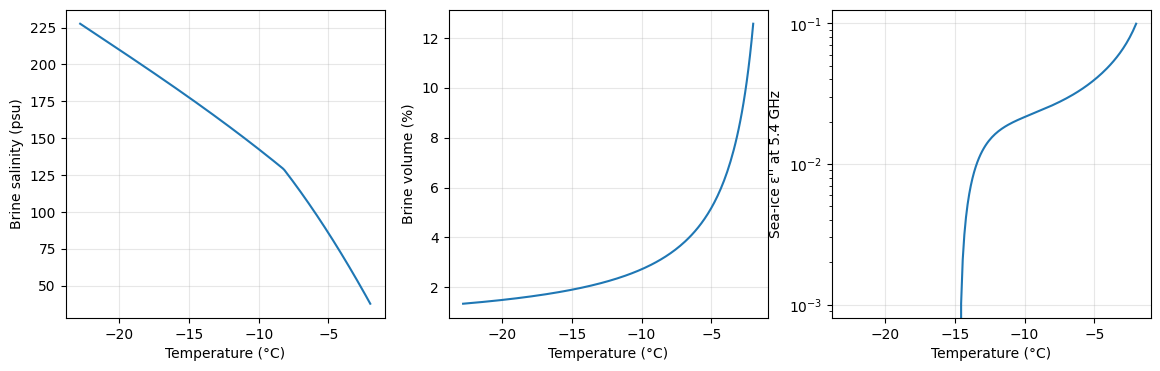

In [7]:
temperature = np.linspace(-22.8, -2, 180)
salinity = brine_salinity(temperature)
volume = brine_volume_fraction(5.0, temperature)
eps_si = np.array([sea_ice_permittivity(5.4, T, 5.0) for T in temperature])
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(temperature, salinity); ax[0].set(ylabel='Brine salinity (psu)')
ax[1].plot(temperature, 100*volume); ax[1].set(ylabel='Brine volume (%)')
ax[2].semilogy(temperature, eps_si.imag); ax[2].set(ylabel="Sea-ice ε'' at 5.4 GHz")
for a in ax: a.set_xlabel('Temperature (°C)'); a.grid(alpha=.3)

## 7. Dry and wet snow

Dry snow is mostly air and ice, so density controls its real permittivity. Adding only a few percent liquid water causes a large loss increase. Radar sensitivity therefore changes qualitatively once melt begins.

[None, None]

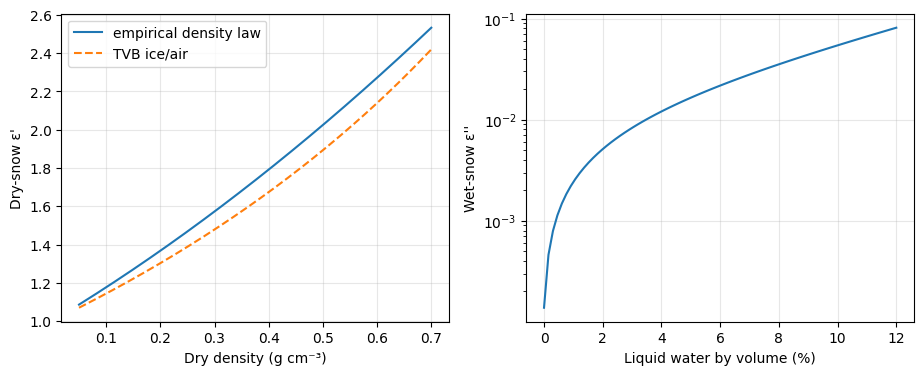

In [8]:
rho = np.linspace(.05, .7, 160)
empirical = dry_snow_permittivity(rho)
tvb_snow = dry_snow_tvb(9.6, rho, -10)
wetness = np.linspace(0, .12, 80)
wet = np.array([wet_snow_permittivity(9.6, .25, w) for w in wetness])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(rho, empirical.real, label='empirical density law'); ax[0].plot(rho, tvb_snow.real, '--', label='TVB ice/air')
ax[1].semilogy(100*wetness, wet.imag)
ax[0].set(xlabel='Dry density (g cm⁻³)', ylabel="Dry-snow ε'"); ax[1].set(xlabel='Liquid water by volume (%)', ylabel="Wet-snow ε''")
ax[0].legend(); [a.grid(alpha=.3) for a in ax]

## 8. Solid and powdered rock

Crushing rock replaces solid volume with air, so powdered-rock permittivity (already covered in Section 4-7.1) depends on bulk density through the TVB mixture below. Solid rock behaves differently: Ulaby et al. (1990a) found its real permittivity $\varepsilon_{sr}'$ to be nearly frequency- and temperature-independent, following the empirical density law of Eq. (4.62), while its loss factor $\varepsilon_{sr}''$ decreases with frequency as $a+b/f$ (Eq. 4.63).

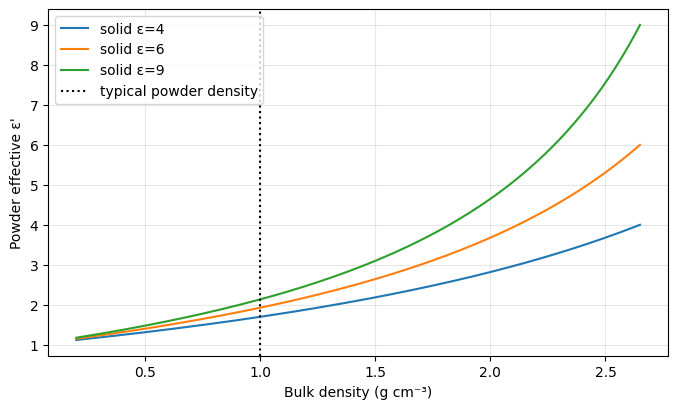

In [9]:
bulk_density = np.linspace(.2, 2.65, 160)
for eps_solid in (4, 6, 9):
    eps_powder = powdered_rock_permittivity(eps_solid, bulk_density)
    plt.plot(bulk_density, eps_powder.real, label=f'solid ε={eps_solid}')
plt.axvline(1, color='k', ls=':', label='typical powder density')
plt.xlabel('Bulk density (g cm⁻³)'); plt.ylabel("Powder effective ε'"); plt.legend(); plt.grid(alpha=.3)

### Solid-rock density and frequency laws (Eqs. 4.62-4.63)

`solid_rock_permittivity` reproduces the $\varepsilon_{sr}'=2^{\rho_b}$ fit of Fig. 4-27. `solid_rock_loss_factor` reproduces the $a+b/f$ frequency roll-off of Fig. 4-28; the constants below are illustrative values within the reported range (0.002-0.24 at 1.6 GHz) rather than a specific measured rock.

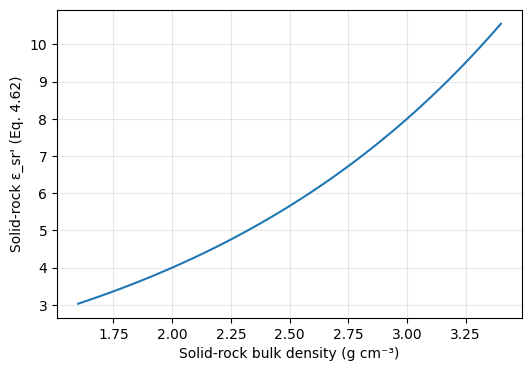

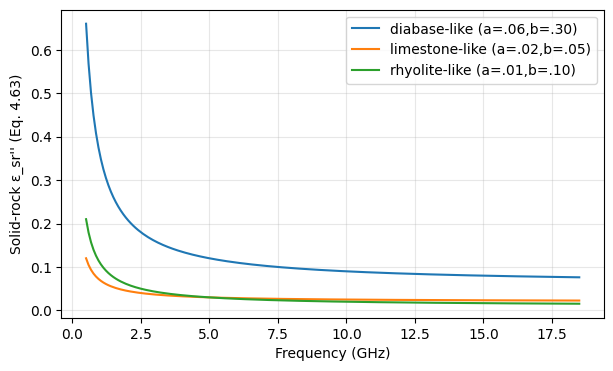

In [10]:
rho_solid = np.linspace(1.6, 3.4, 160)
plt.figure(figsize=(6, 4))
plt.plot(rho_solid, solid_rock_permittivity(rho_solid).real)
plt.xlabel('Solid-rock bulk density (g cm⁻³)')
plt.ylabel("Solid-rock ε_sr' (Eq. 4.62)"); plt.grid(alpha=.3)
plt.show()

freq = np.linspace(0.5, 18.5, 200)
rock_constants = {'diabase-like (a=.06,b=.30)': (.06, .30),
                  'limestone-like (a=.02,b=.05)': (.02, .05),
                  'rhyolite-like (a=.01,b=.10)': (.01, .10)}
plt.figure(figsize=(7, 4))
for label, (a, b) in rock_constants.items():
    plt.plot(freq, solid_rock_loss_factor(freq, a, b), label=label)
plt.xlabel('Frequency (GHz)')
plt.ylabel("Solid-rock ε_sr'' (Eq. 4.63)")
plt.legend(); plt.grid(alpha=.3)

## 9. Soil: dry soil and the Dobson/Peplinski wet-soil model

Dry soil's real permittivity depends only on bulk density (Eq. 4.64). Wet soil is modeled by Dobson et al. (1985) as a four-component mixture—solid soil, air, bound water, and free water—combined with the generalized mixing formula above using $\alpha=0.65$ (Eqs. 4.65-4.69). Peplinski et al. (1995) later refit the effective conductivity term for the 0.3-1.3 GHz band (Eq. 4.70); `dobson_wet_soil_dielectric` exposes both via `band="wideband"` (1.4-18 GHz) and `band="lowband"` (0.3-1.3 GHz).

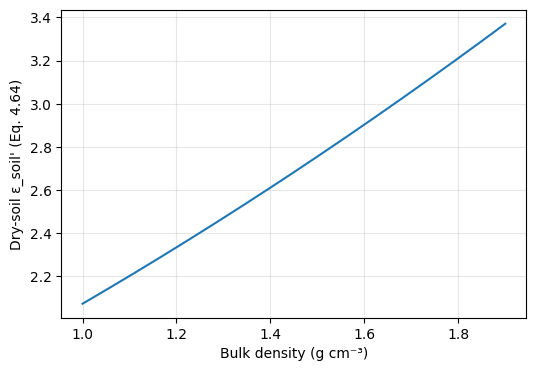

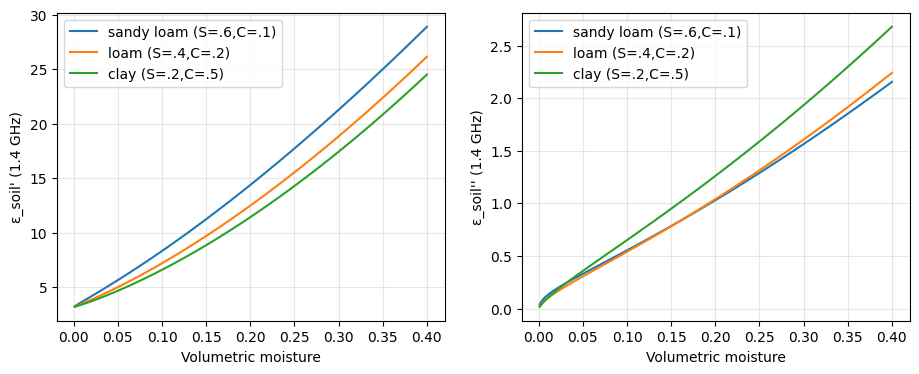

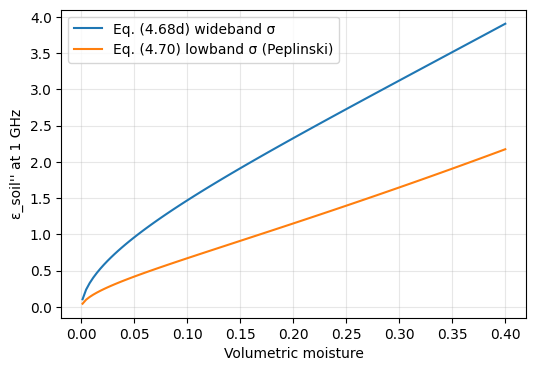

In [11]:
rho_b = np.linspace(1.0, 1.9, 160)
plt.figure(figsize=(6, 4))
plt.plot(rho_b, dry_soil_permittivity(rho_b))
plt.xlabel('Bulk density (g cm⁻³)')
plt.ylabel("Dry-soil ε_soil' (Eq. 4.64)"); plt.grid(alpha=.3)
plt.show()

mv = np.linspace(0.001, 0.4, 120)
textures = {'sandy loam (S=.6,C=.1)': (.6, .1),
            'loam (S=.4,C=.2)': (.4, .2),
            'clay (S=.2,C=.5)': (.2, .5)}
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for label, (S, C) in textures.items():
    eps = dobson_wet_soil_dielectric(mv, freq_ghz=1.4, sand=S, clay=C,
                                     band='lowband')
    ax[0].plot(mv, eps.real, label=label)
    ax[1].plot(mv, eps.imag, label=label)
ax[0].set(xlabel='Volumetric moisture', ylabel="ε_soil' (1.4 GHz)")
ax[1].set(xlabel='Volumetric moisture', ylabel="ε_soil'' (1.4 GHz)")
for a in ax: a.legend(); a.grid(alpha=.3)
plt.show()

# Wideband (Dobson, 1.4-18 GHz) vs lowband (Peplinski, 0.3-1.3 GHz)
# conductivity compared at 1 GHz.
eps_wide = dobson_wet_soil_dielectric(mv, freq_ghz=1.0, sand=.5, clay=.15,
                                      band='wideband')
eps_low = dobson_wet_soil_dielectric(mv, freq_ghz=1.0, sand=.5, clay=.15,
                                     band='lowband')
plt.figure(figsize=(6, 4))
plt.plot(mv, eps_wide.imag, label='Eq. (4.68d) wideband σ')
plt.plot(mv, eps_low.imag, label='Eq. (4.70) lowband σ (Peplinski)')
plt.xlabel('Volumetric moisture'); plt.ylabel("ε_soil'' at 1 GHz")
plt.legend(); plt.grid(alpha=.3)

## 10. Vegetation: free water, bound water, and air

Plant water is divided into free and molecularly bound components. The vegetation-material model first combines residual dry matter with both water states. A second mixing step dilutes plant material with air to represent a sparse canopy.

Canopy fraction 1%: ε = (1.0921488092397085+0.023987321174923807j)
Canopy fraction 3%: ε = (1.2771616970226365+0.0719929652759935j)
Canopy fraction 8%: ε = (1.7442006496147249+0.19221010906331198j)


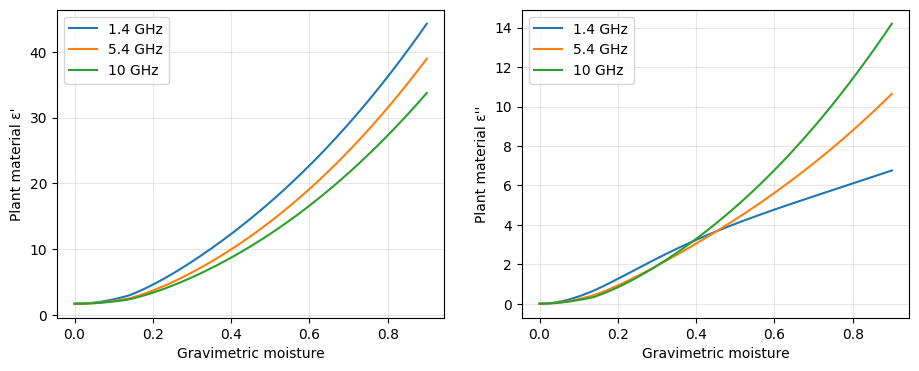

In [12]:
moisture = np.linspace(0, .9, 160)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for fi in (1.4, 5.4, 10):
    plant = vegetation_permittivity(fi, moisture)
    ax[0].plot(moisture, plant.real, label=f'{fi} GHz')
    ax[1].plot(moisture, plant.imag, label=f'{fi} GHz')
ax[0].set(xlabel='Gravimetric moisture', ylabel="Plant material ε'"); ax[1].set(xlabel='Gravimetric moisture', ylabel="Plant material ε''")
for a in ax: a.legend(); a.grid(alpha=.3)
plant = vegetation_permittivity(5.4, .7)
for vf in (.01, .03, .08): print(f'Canopy fraction {vf:.0%}: ε = {canopy_effective_permittivity(plant, vf)}')

## 11. A small sensitivity experiment

A useful modeling habit is to vary uncertain physical inputs instead of reporting a single curve. Below, wet-snow loss is evaluated across density and water fraction. The result reveals where uncertainty in water content matters most.

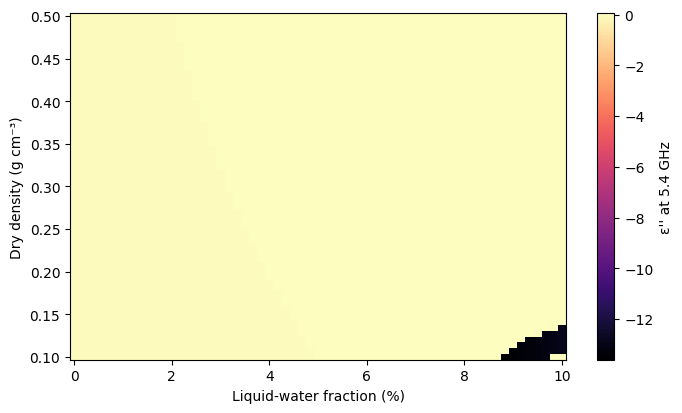

In [13]:
density_grid = np.linspace(.1, .5, 60)
water_grid = np.linspace(0, .1, 61)
loss = np.array([[wet_snow_permittivity(5.4, r, w).imag for w in water_grid] for r in density_grid])
plt.figure(figsize=(8,4.5)); image = plt.pcolormesh(100*water_grid, density_grid, loss, shading='auto', cmap='magma')
plt.xlabel('Liquid-water fraction (%)'); plt.ylabel('Dry density (g cm⁻³)'); plt.colorbar(image, label="ε'' at 5.4 GHz"); plt.grid(False)

## 12. What to remember

1. A dielectric value is incomplete without frequency, temperature, composition, and sign convention.
2. Inclusion geometry can matter as much as volume fraction.
3. Water—especially saline or liquid water—often dominates microwave loss.
4. The generalized power-law formula (Eq. 4.45) shows that "linear," "refractive," and "cubic" mixing are the same equation with different exponents; the Dobson soil model is this same family with $\alpha=0.65$.
5. Solid-rock permittivity is nearly frequency-independent, but its loss factor and dry/wet soil permittivity are strongly density-, texture-, and frequency-dependent.
6. Plant material and a whole canopy are different effective media.
7. Disagreement between defensible mixing rules is model uncertainty worth reporting.
8. Effective-medium models predict bulk propagation; they do not automatically predict backscatter, which also depends on interfaces, roughness, geometry, and spatial fluctuations.